In [1]:
import pandas as pd

# Constants for a 10 MW facility
it_load_kw = 10000 
hours_per_year = 8760
wue_baseline = 1.8 # L/kWh 

# Baseline Calculation
annual_water_liters = it_load_kw * hours_per_year * wue_baseline
print(f"Baseline Annual Water Use: {annual_water_liters:,.2f} Liters")


Baseline Annual Water Use: 157,680,000.00 Liters


In [2]:
import psychrolib

# Set psychrolib to use SI units (Celsius, meters, kilograms)
psychrolib.SetUnitSystem(psychrolib.SI)

# Example: Simulating a humid climate (30°C, 80% Relative Humidity)
temp_c = 30.0
humidity_ratio = 0.80
pressure_pa = 101325  # Standard sea-level atmospheric pressure

# Calculate the actual moisture in the air (Humidity Ratio)
moisture = psychrolib.GetHumRatioFromRelHum(temp_c, humidity_ratio, pressure_pa)
print(f"Moisture available: {moisture} kg of water per kg of dry air")

Moisture available: 0.02157333991480702 kg of water per kg of dry air


In [3]:
from CoolProp.CoolProp import PropsSI

# Parameters at supercritical state
temperature_k = 31.1 + 273.15  # Convert Celsius to Kelvin
pressure_pa = 7.39 * 1000000   # Convert MPa to Pascals

# Calculate Specific Heat Capacity (Cp)
cp_sco2 = PropsSI('C', 'T', temperature_k, 'P', pressure_pa, 'CO2')

print(f"Specific Heat Capacity of sCO2: {cp_sco2:,.2f} J/kg.K")

Specific Heat Capacity of sCO2: 127,234.67 J/kg.K


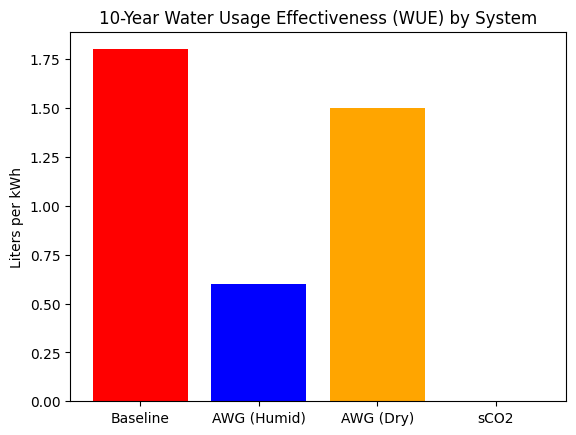

In [4]:
import matplotlib.pyplot as plt

# Sample data dictionary
data = {
    'System': ['Baseline', 'AWG (Humid)', 'AWG (Dry)', 'sCO2'],
    'Net WUE (L/kWh)': [1.8, 0.6, 1.5, 0.0]
}

df = pd.DataFrame(data)

# Create a bar chart
plt.bar(df['System'], df['Net WUE (L/kWh)'], color=['red', 'blue', 'orange', 'green'])
plt.title('10-Year Water Usage Effectiveness (WUE) by System')
plt.ylabel('Liters per kWh')
plt.show()